In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [50]:
observations=10000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

(10000, 2)


In [51]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13*xs + 7*zs + -12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(10000, 1)


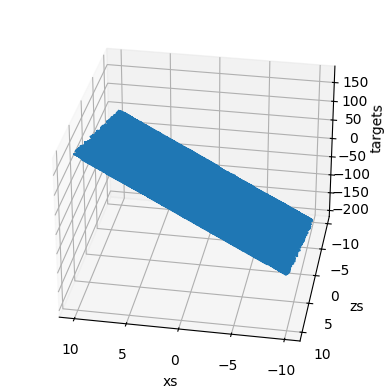

In [52]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')
ax.view_init(azim=100)
plt.show()

In [53]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights)
print(biases)

[[-0.08844784]
 [-0.04838943]]
[0.00459051]


In [60]:
targets = targets.reshape(observations,1)
eta = 0.0001
for i in range (1000):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

0.16938974969520068
0.1693897496949278
0.1693897496946549
0.1693897496943821
0.1693897496941094
0.16938974969383658
0.16938974969356402
0.16938974969329143
0.16938974969301884
0.1693897496927464
0.16938974969247386
0.16938974969220155
0.1693897496919292
0.16938974969165688
0.16938974969138468
0.16938974969111256
0.16938974969084047
0.16938974969056844
0.1693897496902964
0.16938974969002446
0.1693897496897526
0.16938974968948076
0.16938974968920903
0.16938974968893727
0.16938974968866555
0.169389749688394
0.1693897496881224
0.16938974968785087
0.1693897496875795
0.169389749687308
0.16938974968703657
0.16938974968676537
0.16938974968649417
0.169389749686223
0.16938974968595186
0.16938974968568077
0.1693897496854097
0.16938974968513876
0.16938974968486786
0.16938974968459702
0.1693897496843262
0.16938974968405543
0.16938974968378476
0.16938974968351406
0.1693897496832435
0.169389749682973
0.16938974968270254
0.16938974968243203
0.16938974968216167
0.16938974968189138
0.1693897496816211
0.

In [61]:
print(weights, biases)

[[12.99995217]
 [ 7.00007641]] [-11.99673387]


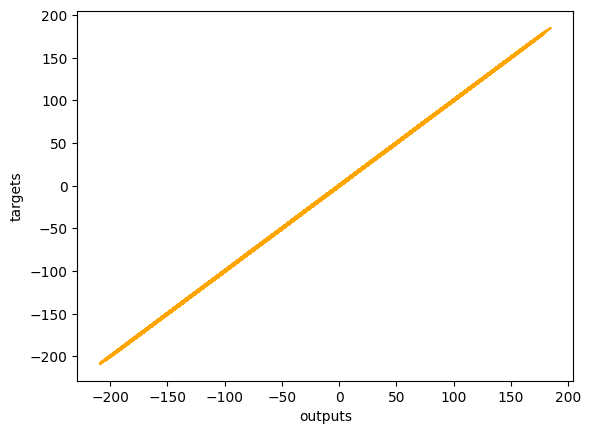

In [62]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()